# XGBOOST — Predikcia priemyselnej produkcie SR

In [2]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from xgboost import XGBRegressor
import shap

import functions
importlib.reload(functions)
from functions import make_features, rolling_forecast_xgb, extract_tree_structure, trace_path_for_observation
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


C:\Users\adamv\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importy uspesne.


In [17]:
#data
DATA_PATH  = r"C:\Users\adamv\Desktop\ADAM\VS\Diplomovka\excel\data_mod.csv"
SHEET_NAME = "data_mod"
TEST_SIZE = 24
N_LAGS = 3
RANDOM_STATE = 24
df_raw = pd.read_csv(DATA_PATH)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

In [18]:
#definovanie features, train/test vzorka
target = "pp_sa"
#exog_cols = ["export_celkovy_sa", "trzby_priemysel_sa", "cpi", "crisis_dummy", "kurz_usd_eur", "unem_prod","inflation"]
exog_cols = df.drop(columns=[target ,"pp"])
features = make_features(data = df, target = target, exog_cols= exog_cols, n_lags = 1)
X = features.drop(columns = [target])
y = features[target]
X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

In [20]:
#tuning hyperparametrov
tscv = TimeSeriesSplit(n_splits=5)

#random_search
random_param_space = {
    "n_estimators": [100, 200, 300, 400, 600],
    "max_depth": [1, 2, 3, 4, 5, 6],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2],
    "gamma": [0, 0.1, 0.5, 1, 5],
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=random_param_space,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)
print("Najlepsie parametre z Random Search:", random_search.best_params_)

best = random_search.best_params_

#grid_search
grid_param_space = {
    "n_estimators": sorted(set([max(50, best["n_estimators"] - 100), best["n_estimators"], best["n_estimators"] + 100])),
    "max_depth": sorted(set([max(1, best["max_depth"] - 1), best["max_depth"], best["max_depth"] + 1])),
    "learning_rate": sorted(set([round(best["learning_rate"] * 0.5, 4), best["learning_rate"], round(best["learning_rate"] * 1.5, 4)])),
    "gamma": sorted(set([max(0, best["gamma"] - 1), best["gamma"], best["gamma"] + 1])),
    "subsample": [best["subsample"]],
    "colsample_bytree": [best["colsample_bytree"]],
    "min_child_weight": [best["min_child_weight"]],
    "reg_alpha": [best["reg_alpha"]],
    "reg_lambda": [best["reg_lambda"]],
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_grid=grid_param_space,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Finalne parametre po Grid Search:", best_params)

Najlepsie parametre z Random Search: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 0.5, 'colsample_bytree': 0.9}
Finalne parametre po Grid Search: {'colsample_bytree': 0.9, 'gamma': 0.5, 'learning_rate': 0.0075, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1.0}


In [21]:
#porovnanie priemerného CV RMSE pre max_depth=1 vs. max_depth=2
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[["param_max_depth", "mean_test_score", "std_test_score"]].sort_values("param_max_depth")

,param_max_depth,mean_test_score,std_test_score
0,3,-3.759505,1.122954
1,3,-3.649907,1.080645
2,3,-3.585561,1.073348
9,3,-3.651915,1.078746
10,3,-3.534258,1.070509
...,...,...,...
71,5,-3.504422,1.096823
70,5,-3.521181,1.104361
78,5,-3.559711,1.116796
79,5,-3.510025,1.100281


In [22]:
cv_results = pd.DataFrame(grid_search.cv_results_)

depth_summary = (
    cv_results
    .groupby("param_max_depth")
    .agg(
        best_rmse=("mean_test_score", lambda x: -x.max()),
        mean_rmse=("mean_test_score", lambda x: -x.mean()),
        std_cv=("std_test_score", "mean"),
        n_models=("mean_test_score", "count")
    )
    .reset_index()
    .sort_values("best_rmse")
)

depth_summary

,param_max_depth,best_rmse,mean_rmse,std_cv,n_models
1,4,3.464369,3.564330,1.096176,27
2,5,3.489695,3.571284,1.113485,27
0,3,3.500151,3.587586,1.073919,27


In [23]:
#trenovanie a rmse modelu
init_train_size = len(y) - TEST_SIZE
results, last_model = rolling_forecast_xgb(X, y, initial_train_size = init_train_size, refit_every= N_LAGS, objective =  "reg:squarederror", xgb_params=best_params)
rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
print(f"XGBoost rolling forecast RMSE: {rmse:.4f}")

XGBoost rolling forecast RMSE: 2.3515


In [24]:
init_train_size = len(y) - TEST_SIZE
REFIT_FREQ  = [1,3,5]

In [25]:
#shap
explainer = shap.TreeExplainer(last_model)
shap_values = explainer.shap_values(X_test)
shap_summary = pd.DataFrame(shap_values, columns = X_test.columns, index = X_test.index)
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)
mean_abs_shap

trzby_priemysel_sa                1.078940
export_celkovy_sa                 0.388891
pp_sa_lag1                        0.180184
trend                             0.155642
vklady_nefinancne_podniky         0.118154
uvery_celkom_lag1                 0.074925
cpi                               0.053111
vklady_nefinancne_podniky_lag1    0.051434
month                             0.048302
uvery_celkom                      0.047225
export_celkovy_sa_lag1            0.047135
inflation                         0.032917
ipcv_priemysel_lag1               0.022509
fin_stock                         0.021372
kurz_usd_eur                      0.018471
cpi_lag1                          0.012955
unem_prod                         0.012210
fin_stock_lag1                    0.010974
ipcv_priemysel                    0.010512
sadzba_3m_euribor                 0.010498
unem_prod_lag1                    0.008218
trzby_priemysel_sa_lag1           0.006242
kurz_usd_eur_lag1                 0.003628
sadzba_3m_e

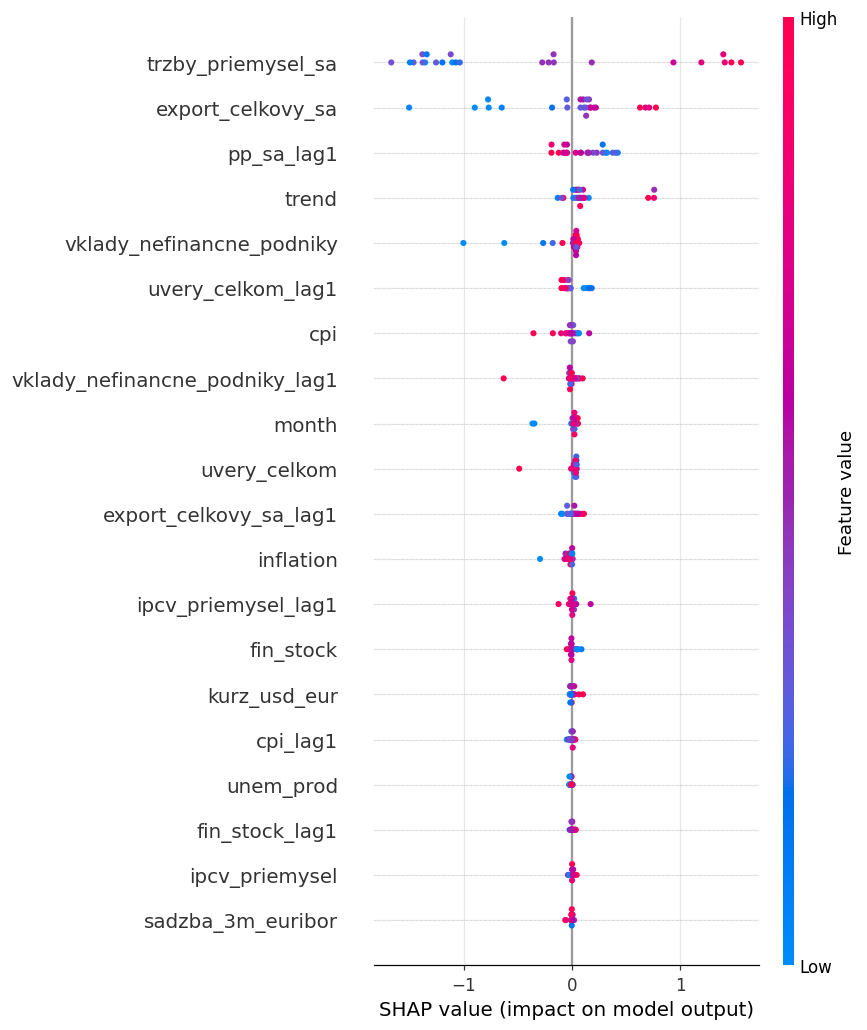

In [26]:
#graf ku shapu
shap.summary_plot(shap_values, X_test)

In [27]:
trees_df = extract_tree_structure(last_model)
trees_df

,Tree,Target,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0,0-0,trzby_priemysel_sa,35.59,0-1,0-2,0-2,750.9018,307.0,None
1,0,0,1,0-1,trzby_priemysel_sa,-743.23,0-3,0-4,0-4,463.1744,157.0,None
2,0,0,2,0-2,export_celkovy_sa,816.69,0-5,0-6,0-6,148.38394,150.0,None
3,0,0,3,0-3,ipcv_priemysel,-0.2,0-7,0-8,0-8,3.760925,4.0,None
4,0,0,4,0-4,pp_sa_lag1,7.91,0-9,0-10,0-10,212.3057,153.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...
6697,299,0,20,299-20,Leaf,<NA>,<NA>,<NA>,<NA>,0.007406,13.0,None
6698,299,0,21,299-21,Leaf,<NA>,<NA>,<NA>,<NA>,0.001302,14.0,None
6699,299,0,22,299-22,Leaf,<NA>,<NA>,<NA>,<NA>,0.019385,7.0,None
6700,299,0,23,299-23,Leaf,<NA>,<NA>,<NA>,<NA>,-0.004068,84.0,None


In [28]:
# iba listove uzly (vahy) jedneho konkretneho stromu
tree_0_leaves = trees_df[(trees_df["Tree"] == 0) & (trees_df["Feature"] == "Leaf")]
print(tree_0_leaves[["Tree", "Node", "Gain", "Cover"]])

    Tree  Node      Gain  Cover
6      0     6   0.05738    3.0
7      0     7 -0.091063    3.0
8      0     8 -0.023984    1.0
10     0    10 -0.071704    2.0
13     0    13 -0.019826   41.0
14     0    14 -0.003089  110.0
15     0    15 -0.014948    5.0
16     0    16  0.012564  140.0
17     0    17 -0.044234    1.0
18     0    18 -0.007746    1.0


In [29]:
#najcastejsie pouzivane premenne na delenie
split_counts = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")
    .size()
    .sort_values(ascending=False)
)
print(split_counts)

Feature
pp_sa_lag1                        522
export_celkovy_sa                 495
trzby_priemysel_sa                492
trend                             185
vklady_nefinancne_podniky_lag1    177
cpi                               172
export_celkovy_sa_lag1            150
vklady_nefinancne_podniky         105
uvery_celkom_lag1                 103
cpi_lag1                           93
unem_prod_lag1                     92
uvery_celkom                       67
ipcv_priemysel_lag1                63
fin_stock                          61
month                              56
inflation                          52
unem_prod                          48
fin_stock_lag1                     42
kurz_usd_eur_lag1                  41
trzby_priemysel_sa_lag1            40
ipcv_priemysel                     37
kurz_usd_eur                       32
sadzba_3m_euribor                  31
sadzba_3m_euribor_lag1             30
crisis_dummy                       10
inflation_lag1                      4
quar

In [30]:
#priemerny Gain pri deleni podla premennej
avg_gain_by_feature = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")["Gain"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_gain_by_feature)

Feature
trzby_priemysel_sa                171.183817
export_celkovy_sa                  80.435987
pp_sa_lag1                         57.275583
sadzba_3m_euribor                   56.33693
uvery_celkom                       50.101906
unem_prod_lag1                     47.113836
vklady_nefinancne_podniky_lag1     46.756205
vklady_nefinancne_podniky           43.08487
crisis_dummy                       39.690687
sadzba_3m_euribor_lag1             38.242731
unem_prod                          37.264471
inflation                          34.502852
export_celkovy_sa_lag1              32.93319
inflation_lag1                     29.116753
month                              28.254385
uvery_celkom_lag1                  28.067893
kurz_usd_eur                        27.22557
trend                              26.233424
trzby_priemysel_sa_lag1            24.303638
kurz_usd_eur_lag1                  22.573624
ipcv_priemysel                     20.198219
fin_stock                           19.84537
fi

In [31]:
#kompletna struktura jedneho konkretneho stromu
tree_0_full = trace_path_for_observation(trees_df, tree_index=99)
print(tree_0_full)

      Node                         Feature   Split    Yes     No       Gain  \
2083     0               export_celkovy_sa -156.53   99-1   99-2  225.86493   
2084     1               export_celkovy_sa -667.88   99-3   99-4  98.795975   
2085     2                      pp_sa_lag1    0.29   99-5   99-6   95.34453   
2086     3                            Leaf    <NA>   <NA>   <NA>  -0.058558   
2087     4                           trend   272.0   99-7   99-8  26.169746   
2088     5  vklady_nefinancne_podniky_lag1  1011.0   99-9  99-10    52.5437   
2089     6         trzby_priemysel_sa_lag1  968.08  99-11  99-12   89.17302   
2090     7                       unem_prod    -0.1  99-13  99-14   23.02745   
2091     8                       fin_stock    -1.0  99-15  99-16    8.49135   
2092     9                      pp_sa_lag1   -4.26  99-17  99-18   47.85367   
2093    10                            Leaf    <NA>   <NA>   <NA>  -0.031705   
2094    11                      pp_sa_lag1    9.67  

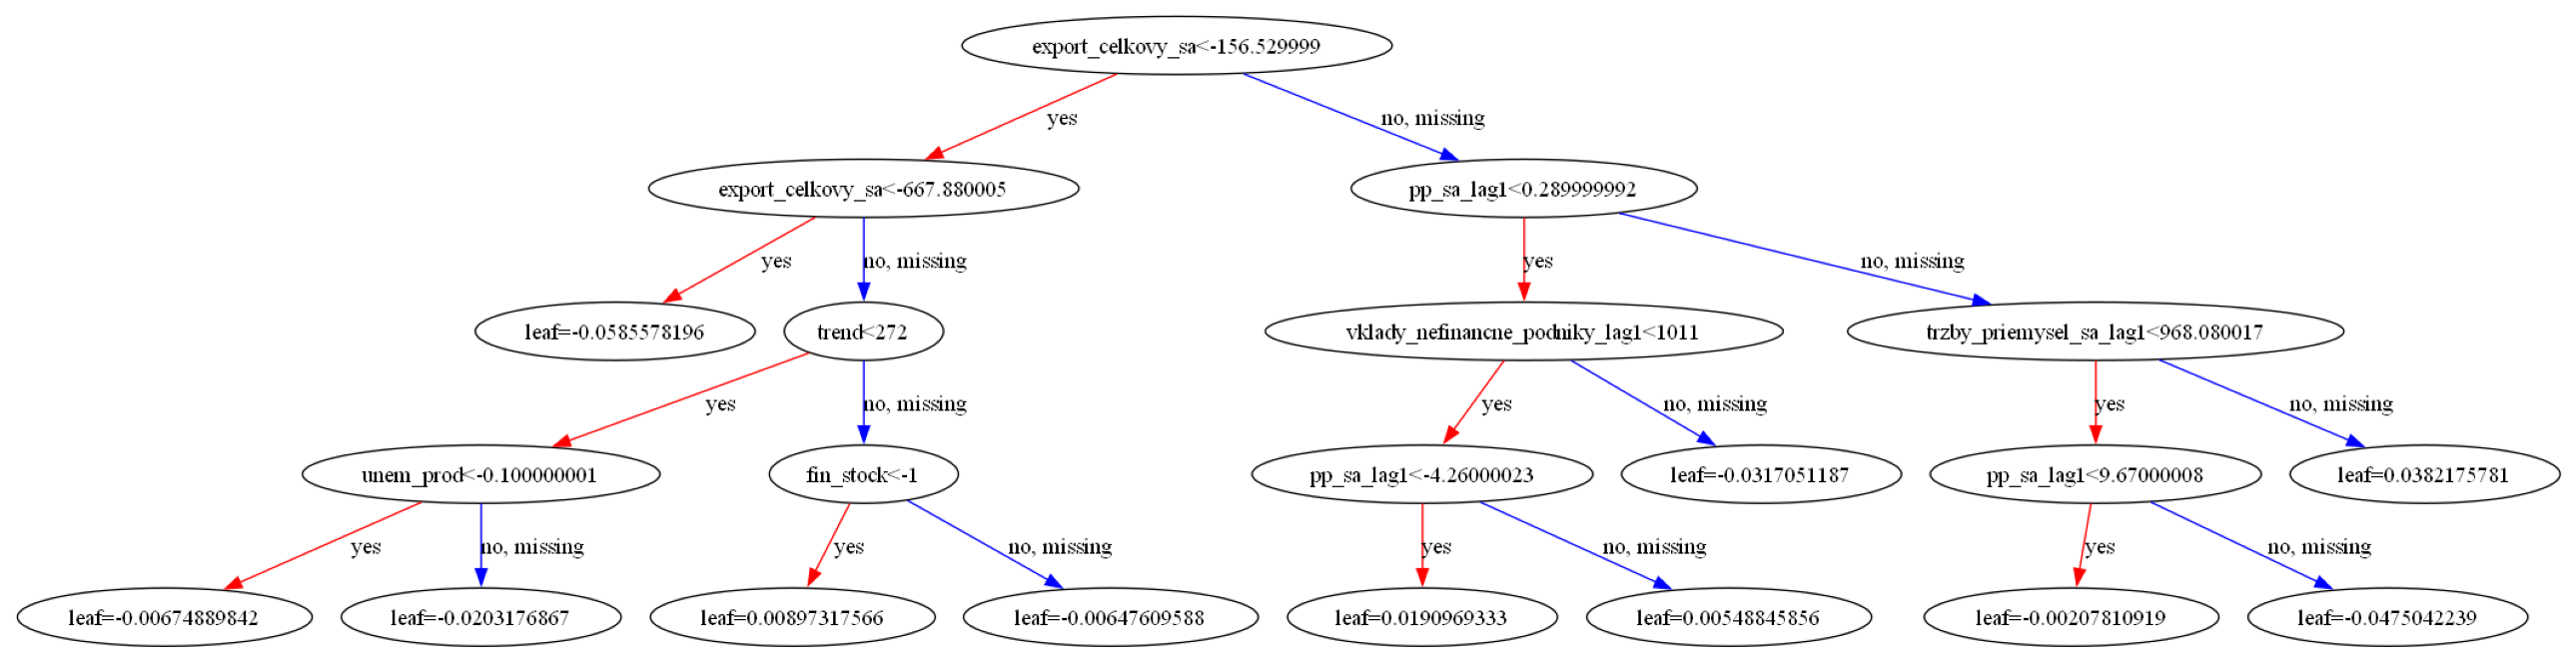

In [32]:
#graficke zobrazenie stromu
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(last_model, num_trees=99)
fig = plt.gcf()
fig.set_size_inches(30, 15)

In [33]:
#Pocet listov a vnutornych uzlov pre kazdy strom
tree_summary = trees_df.groupby("Tree").agg(
    n_nodes=("Node", "count"),
    n_leaves=("Feature", lambda x: (x == "Leaf").sum()),
).reset_index()

# pre binarny strom: n_splits = n_leaves - 1
tree_summary["n_splits"] = tree_summary["n_leaves"] - 1

In [34]:
#Zakladna statistika - kolko stromov ma 0, 1, 2+ deleni
split_distribution = tree_summary["n_splits"].value_counts().sort_index()
print("Rozdelenie poctu deleni naprieč stromami:")
print(split_distribution)

n_trivial = (tree_summary["n_splits"] == 0).sum()
n_single_split = (tree_summary["n_splits"] == 1).sum()
n_multi_split = (tree_summary["n_splits"] > 1).sum()

print(f"\nStromy bez delenia (len 1 list):       {n_trivial}")
print(f"Stromy s presne 1 delenim (2 listy):    {n_single_split}")
print(f"Stromy s viac ako 1 delenim (3+ listy): {n_multi_split}")


Rozdelenie poctu deleni naprieč stromami:
n_splits
7     20
8     27
9     39
10    41
11    75
12    51
13    12
14    34
15     1
Name: count, dtype: int64

Stromy bez delenia (len 1 list):       0
Stromy s presne 1 delenim (2 listy):    0
Stromy s viac ako 1 delenim (3+ listy): 300


In [35]:
#ktore konkretne stromy maju viac ako 1 delenie
trees_with_multi_splits = tree_summary[tree_summary["n_splits"] > 1].sort_values(
    "n_splits", ascending=False
)
print("\nStromy s viac ako 1 delenim (zoradene podla poctu deleni):")
print(trees_with_multi_splits)


Stromy s viac ako 1 delenim (zoradene podla poctu deleni):
     Tree  n_nodes  n_leaves  n_splits
275   275       31        16        15
274   274       29        15        14
272   272       29        15        14
296   296       29        15        14
258   258       29        15        14
..    ...      ...       ...       ...
96     96       15         8         7
79     79       15         8         7
41     41       15         8         7
38     38       15         8         7
30     30       15         8         7

[300 rows x 4 columns]


In [36]:
# Priemerny pocet deleni cez cely ansambel - rychly diagnosticky ukazovatel
avg_splits = tree_summary["n_splits"].mean()
pct_trivial = (n_trivial / len(tree_summary)) * 100
print(f"\nPriemerny pocet deleni na strom: {avg_splits:.2f}")
print(f"Podiel trivialnych (nerozdelenych) stromov: {pct_trivial:.1f}%")


Priemerny pocet deleni na strom: 10.67
Podiel trivialnych (nerozdelenych) stromov: 0.0%
